# AUCROC Analysis using Quality Metrics

This notebook contains AUCROC (Area Under the Curve - Receiver Operating Characteristic) analysis and plotting functionality used in UnitRefine paper for evaluating the performance of different quality metrics in distinguishing noise from single-unit activity. 
(Note: In the paper, figure 2 shows AUCROC on 7 high-quality recordings. Here we are plotting on the 11 base-dataset.)


In [1]:
# Import required libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.metrics import roc_curve, auc
from scipy.stats import wilcoxon
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300


## Configuration and Data Paths

In [2]:
# Define data directories - Update these paths as needed
noise_data_directory = r'Y:\Projects\UnitRefine\dataset_for_plotting\noise_data_for_paper'
sua_data_directory = r'Y:\Projects\UnitRefine\dataset_for_plotting\sua_data_for_paper'

# Alternative local paths 
# noise_data_directory = r'data\noise_data_for_paper'
# sua_data_directory = r'data\sua_data_for_paper'

# Create output directory for plots
output_dir = r'E:\UnitRefine\outputs\aucroc_plots'
os.makedirs(output_dir, exist_ok=True)

print(f"Output directory created: {output_dir}")
print(f"Noise data path: {noise_data_directory}")
print(f"SUA data path: {sua_data_directory}")

Output directory created: E:\UnitRefine\outputs\aucroc_plots
Noise data path: Y:\Projects\UnitRefine\dataset_for_plotting\noise_data_for_paper
SUA data path: Y:\Projects\UnitRefine\dataset_for_plotting\sua_data_for_paper


## Metric Categories Definition

In [3]:
# Define metric categories
quality_metrics =  ['firing_rate', 'presence_ratio', 'snr', 'isi_violations_ratio', 'isi_violations_count',
                'rp_contamination', 'rp_violations', 'sliding_rp_violation', 'amplitude_cutoff', 
                'drift_ptp', 'isolation_distance', 'l_ratio', 'd_prime', 'sd_ratio',
                'silhouette', 'nn_hit_rate', 'nn_miss_rate','amplitude_median']
new_metrics = [ 
                'amplitude_cv_median', 'amplitude_cv_range', 'sync_spike_2', 'sync_spike_4', 'sync_spike_8',
                'firing_range']
template_metrics = [ 'peak_to_valley', 'peak_trough_ratio', 'half_width', 'velocity_above', 'velocity_below',
                'repolarization_slope', 'recovery_slope', 'num_positive_peaks', 'num_negative_peaks', 'exp_decay', 'spread']

all_metrics = quality_metrics + new_metrics + template_metrics

# Define colors for different metric categories
metric_colors = {
    'quality':'#E74C3C',      # Red
    'new':'#3498DB',          # Blue  
    'template': '#2ECC71'      # Green
}

# Create color dictionary for individual metrics
colors_dict = {}
for metric in quality_metrics:
    colors_dict[metric] = metric_colors['quality']
for metric in new_metrics:
    colors_dict[metric] = metric_colors['new']
for metric in template_metrics:
    colors_dict[metric] = metric_colors['template']

print(f"Total metrics defined: {len(all_metrics)}")
print(f"Quality metrics: {len(quality_metrics)}")
print(f"New metrics: {len(new_metrics)}")
print(f"Template metrics: {len(template_metrics)}")

Total metrics defined: 35
Quality metrics: 18
New metrics: 6
Template metrics: 11


## Data Loading Functions

In [11]:
def load_data_files(directory_path, target_column='is_noise'):
    """
    Load all CSV files from a directory and return combined dataframes
    
    Parameters:
    - directory_path: Path to directory containing CSV files
    - target_column: Name of target variable column
    
    Returns:
    - combined_df: Combined dataframe with all data
    - list_of_dataframes: List of individual dataframes per file
    """
    if not os.path.exists(directory_path):
        print(f"Warning: Directory {directory_path} does not exist")
        return pd.DataFrame(), []
    
    files = os.listdir(directory_path)
    list_of_dataframes = []
    
    print(f"Found {len([f for f in files if f.endswith('.csv')])} CSV files in {directory_path}")
    
    for file in files:
        if file.endswith('.csv'):
            file_path = os.path.join(directory_path, file)
            try:
                df = pd.read_csv(file_path)
                
                # Drop unnecessary columns
                columns_to_drop = ['Unnamed: 0', 'cluster_id', 'majority_vote', 
                                 'drift_std', 'drift_mad', 'num_spikes']
                df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')
                
                list_of_dataframes.append(df)
            except Exception as e:
                print(f"  Error loading {file}: {e}")
    
    if list_of_dataframes:
        # Combine all dataframes
        combined_df = pd.concat(list_of_dataframes, axis=0, ignore_index=True)
        print(f"Combined dataframe shape: {combined_df.shape}")
    else:
        combined_df = pd.DataFrame()
        print("No data loaded")
    
    return combined_df, list_of_dataframes

## Load Data

In [12]:
# Load noise data
print("=== LOADING NOISE DATA ===")
noise_combined_df, noise_dataframes = load_data_files(noise_data_directory)

print("\n=== LOADING SUA DATA ===")
sua_combined_df, sua_dataframes = load_data_files(sua_data_directory)

# Display available columns
if not noise_combined_df.empty:
    print(f"\nNoise data columns: {list(noise_combined_df.columns)}")
if not sua_combined_df.empty:
    print(f"\nSUA data columns: {list(sua_combined_df.columns)}")

=== LOADING NOISE DATA ===
Found 11 CSV files in Y:\Projects\UnitRefine\dataset_for_plotting\noise_data_for_paper
Combined dataframe shape: (5121, 36)

=== LOADING SUA DATA ===
Found 11 CSV files in Y:\Projects\UnitRefine\dataset_for_plotting\sua_data_for_paper
Combined dataframe shape: (3690, 36)

Noise data columns: ['amplitude_cutoff', 'amplitude_cv_median', 'amplitude_cv_range', 'amplitude_median', 'drift_ptp', 'firing_range', 'firing_rate', 'isi_violations_ratio', 'isi_violations_count', 'presence_ratio', 'rp_contamination', 'rp_violations', 'sd_ratio', 'sliding_rp_violation', 'snr', 'sync_spike_2', 'sync_spike_4', 'sync_spike_8', 'd_prime', 'isolation_distance', 'l_ratio', 'silhouette', 'nn_hit_rate', 'nn_miss_rate', 'exp_decay', 'half_width', 'num_negative_peaks', 'num_positive_peaks', 'peak_to_valley', 'peak_trough_ratio', 'recovery_slope', 'repolarization_slope', 'spread', 'velocity_above', 'velocity_below', 'is_noise']

SUA data columns: ['amplitude_cutoff', 'amplitude_cv_med

## AUCROC Calculation Functions

In [6]:
def calculate_aucroc_per_dataset(dataframes_list, target_column='is_noise'):
    """
    Calculate AUCROC values for each dataset separately
    
    Parameters:
    - dataframes_list: List of dataframes
    - target_column: Name of target variable column
    
    Returns:
    - auc_df: DataFrame with AUC values per dataset
    """
    if not dataframes_list:
        return pd.DataFrame()
    
    auc_values_list = []
    
    for i, df in enumerate(dataframes_list):
        print(f"Processing dataset {i+1}/{len(dataframes_list)}...")
        auc_values_dict = {}
        
        if target_column not in df.columns:
            print(f"  Warning: Target column '{target_column}' not found")
            continue
        
        for feature_column in df.columns:
            if feature_column != target_column:
                try:
                    actual = df[target_column]
                    prediction = df[feature_column]
                    
                    # Remove NaN and infinite values
                    mask = ~(pd.isna(actual) | pd.isna(prediction) | np.isinf(actual) | np.isinf(prediction))
                    actual_clean = actual[mask]
                    prediction_clean = prediction[mask]
                    
                    if len(actual_clean) > 0 and len(np.unique(actual_clean)) > 1:
                        fpr, tpr, thresholds = roc_curve(actual_clean, prediction_clean)
                        roc_auc = auc(fpr, tpr)
                        auc_values_dict[feature_column] = roc_auc
                except Exception as e:
                    print(f"    Error calculating AUC for {feature_column}: {e}")
                    continue
        
        auc_values_list.append(auc_values_dict)
    
    result_df = pd.DataFrame(auc_values_list)
    print(f"AUCROC calculation completed. Result shape: {result_df.shape}")
    
    return result_df


## Calculate AUCROC Values

In [7]:
# Calculate AUCROC for noise data
print("=== CALCULATING AUCROC FOR NOISE DATA ===")
noise_auc_df = calculate_aucroc_per_dataset(noise_dataframes, target_column='is_noise')

print("\n=== CALCULATING AUCROC FOR SUA DATA ===")
sua_auc_df = calculate_aucroc_per_dataset(sua_dataframes, target_column='is_sua')

print("\n=== AUCROC CALCULATION SUMMARY ===")
print(f"Noise AUC DataFrame: {noise_auc_df.shape if not noise_auc_df.empty else 'No data'}")
print(f"SUA AUC DataFrame: {sua_auc_df.shape if not sua_auc_df.empty else 'No data'}")

=== CALCULATING AUCROC FOR NOISE DATA ===
Processing dataset 1/11...
Processing dataset 2/11...
Processing dataset 3/11...
Processing dataset 4/11...
Processing dataset 5/11...
Processing dataset 6/11...
Processing dataset 7/11...
Processing dataset 8/11...
Processing dataset 9/11...
Processing dataset 10/11...
Processing dataset 11/11...
AUCROC calculation completed. Result shape: (11, 35)

=== CALCULATING AUCROC FOR SUA DATA ===
Processing dataset 1/11...
Processing dataset 2/11...
Processing dataset 3/11...
Processing dataset 4/11...
Processing dataset 5/11...
Processing dataset 6/11...
Processing dataset 7/11...
Processing dataset 8/11...
Processing dataset 9/11...
Processing dataset 10/11...
Processing dataset 11/11...
AUCROC calculation completed. Result shape: (11, 35)

=== AUCROC CALCULATION SUMMARY ===
Noise AUC DataFrame: (11, 35)
SUA AUC DataFrame: (11, 35)


## AUCROC Plotting Functions

In [8]:
def plot_aucroc_boxplot(auc_df, title, colors_dict=None, figsize=(12, 8), save_path=None):
    """
    Create boxplot of AUCROC values with color-coded metrics
    """
    if auc_df.empty:
        print(f"No data to plot for {title}")
        return

    plt.figure(figsize=figsize)

    # Sort metrics by mean AUC value (distance from 0.5)
    mean_distances = auc_df.mean().abs().sub(0.5).abs()
    sorted_index = mean_distances.sort_values(ascending=True).index
    df_sorted = auc_df[sorted_index]

    # Create boxplot
    if colors_dict:
        palette = [colors_dict.get(col, 'gray') for col in sorted_index]
        ax = sns.boxplot(data=df_sorted, orient='h', palette=palette)
    else:
        ax = sns.boxplot(data=df_sorted, orient='h')

    # Add chance level line
    plt.axvline(0.5, color='red', linestyle='--', alpha=0.8, linewidth=2, label='Chance level')

    # Formatting
    plt.xlabel('AUC Values', fontsize=14, fontweight='bold')
    plt.ylabel('Features', fontsize=14, fontweight='bold')
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.grid(True, alpha=0.3)

    # Add legend for metric categories
    if colors_dict:
        legend_elements = [
            plt.Rectangle((0, 0), 1, 1, color=metric_colors['quality'], label='Quality Metrics'),
            plt.Rectangle((0, 0), 1, 1, color=metric_colors['new'], label='New Metrics'),
            plt.Rectangle((0, 0), 1, 1, color=metric_colors['template'], label='Template Metrics'),
            plt.Line2D([0], [0], color='red', linestyle='--', label='Chance Level')
        ]
        plt.legend(handles=legend_elements, loc='lower right', fontsize=12)

    plt.tight_layout()

    if save_path:
        full_path = os.path.join(output_dir, save_path)
        plt.savefig(full_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {full_path}")

    plt.show()


def plot_aucroc_with_significance(auc_df, title, figsize=(14, 6), save_path=None):
    """
    Plot AUC ROC boxplots with significance stars, grouped and sorted.

    Groups shown in order: template metrics, quality metrics, new metrics.
    Within each group, metrics are sorted from high to low by mean AUC.
    Individual datapoints from each dataframe are overlaid.
    """
    if auc_df.empty:
        print(f"No data to plot for {title}")
        return

    # Determine columns present and group them
    available_cols = [c for c in auc_df.columns]

    # Use metric groups defined earlier in the notebook if available
    template_cols = [c for c in template_metrics if c in available_cols] if 'template_metrics' in globals() else []
    quality_cols = [c for c in quality_metrics if c in available_cols] if 'quality_metrics' in globals() else []
    new_cols = [c for c in new_metrics if c in available_cols] if 'new_metrics' in globals() else []

    # Sort each group by mean AUC descending
    def sort_by_mean_desc(cols):
        if not cols:
            return []
        means = auc_df[cols].mean().sort_values(ascending=False)
        return list(means.index)

    template_sorted = sort_by_mean_desc(template_cols)
    quality_sorted = sort_by_mean_desc(quality_cols)
    new_sorted = sort_by_mean_desc(new_cols)

    # Combine in requested order: templates, then quality, then new
    ordered_columns = template_sorted + quality_sorted + new_sorted

    # If there are any remaining columns not in the groups, append them at the end
    remaining = [c for c in available_cols if c not in ordered_columns]
    ordered_columns += remaining

    # Reorder dataframe for plotting
    df_ordered = auc_df[ordered_columns]

    fig, ax = plt.subplots(figsize=figsize)

    # Boxplot (vertical) for each ordered column
    box = ax.boxplot([df_ordered[col].dropna() for col in df_ordered.columns],
                     positions=np.arange(len(df_ordered.columns)) + 1,
                     widths=0.6,
                     patch_artist=True)

    # Chance level line
    ax.axhline(0.5, color="red", linestyle="--", alpha=0.8, linewidth=2, label="Chance level")

    # Color boxes by category, with fallback to light gray for unclassified metrics
    for patch, col in zip(box['boxes'], df_ordered.columns):
        color = colors_dict.get(col, '#D3D3D3') if col in colors_dict else '#D3D3D3'
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    # Overlay individual datapoints (jittered) for each column
    for i, col in enumerate(df_ordered.columns, start=1):
        values = df_ordered[col].dropna().values
        if len(values) == 0:
            continue
        jitter = np.random.normal(loc=0, scale=0.06, size=len(values))
        x_positions = np.full_like(values, i, dtype=float) + jitter
        ax.scatter(x_positions, values, color='black', alpha=0.6, s=10)

    # Annotate significance per column using Wilcoxon against 0.5
    for i, col in enumerate(df_ordered.columns, start=1):
        values = df_ordered[col].dropna().values
        if len(values) == 0:
            continue
        try:
            if np.mean(values) > 0.5:
                stat, p_value = wilcoxon(values - 0.5, alternative="greater")
                y_pos = np.max(values) + 0.02
                va = 'bottom'
            else:
                stat, p_value = wilcoxon(values - 0.5, alternative="less")
                y_pos = np.min(values) - 0.02
                va = 'top'
        except Exception:
            p_value = 1.0
            y_pos = np.mean(values)
            va = 'center'

        if p_value < 0.001:
            stars = "***"
        elif p_value < 0.01:
            stars = "**"
        elif p_value < 0.05:
            stars = "*"
        else:
            stars = "ns"

        if stars != "ns":
            ax.text(i, y_pos, stars, ha="center", va=va, fontsize=12, fontweight='bold', color='black')

    # Formatting
    ax.set_xticks(np.arange(len(df_ordered.columns)) + 1)
    ax.set_xticklabels(df_ordered.columns, rotation=45, ha='right', fontsize=10)
    ax.set_ylabel('AUC Values', fontsize=14, fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=16, pad=20)
    ax.grid(True, alpha=0.3)

    # Build legend for categories if possible
    legend_elements = []
    if 'metric_colors' in globals():
        if any(c in df_ordered.columns for c in template_cols):
            legend_elements.append(plt.Rectangle((0, 0), 1, 1, color=metric_colors.get('template', '#2ECC71'), label='Template Metrics'))
        if any(c in df_ordered.columns for c in quality_cols):
            legend_elements.append(plt.Rectangle((0, 0), 1, 1, color=metric_colors.get('quality', '#E74C3C'), label='Quality Metrics'))
        if any(c in df_ordered.columns for c in new_cols):
            legend_elements.append(plt.Rectangle((0, 0), 1, 1, color=metric_colors.get('new', '#3498DB'), label='New Metrics'))
    # legend_elements.append(plt.Line2D([0], [0], color='red', linestyle='--', label='Chance Level'))
    # ax.legend(handles=legend_elements, loc='lower right', fontsize=12)

    plt.tight_layout()

    if save_path:
        full_path = os.path.join(output_dir, save_path)
        plt.savefig(full_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {full_path}")

    plt.show()


## Generate AUCROC Plots for Noise Data

Plot saved to: E:\UnitRefine\outputs\aucroc_plots\noise_aucroc_significance.png


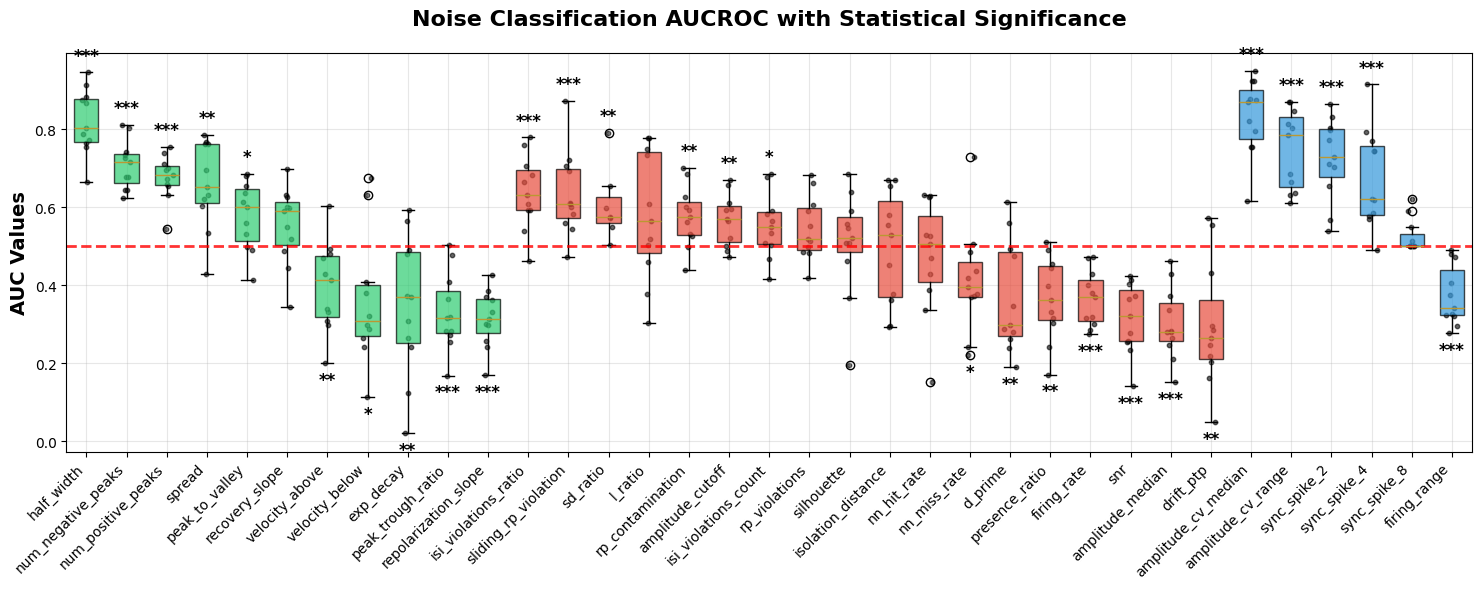

In [ ]:
# Significance plot for noise data
if not noise_auc_df.empty:
    plot_aucroc_with_significance(
        noise_auc_df,
        title='Noise Classification AUCROC with Statistical Significance',
        figsize=(15, 6),
        save_path='noise_aucroc_significance.png'
    )
else:
    print("No noise data available for significance testing")

## Generate AUCROC Plots for SUA Data

Plot saved to: E:\UnitRefine\outputs\aucroc_plots\sua_aucroc_significance.png


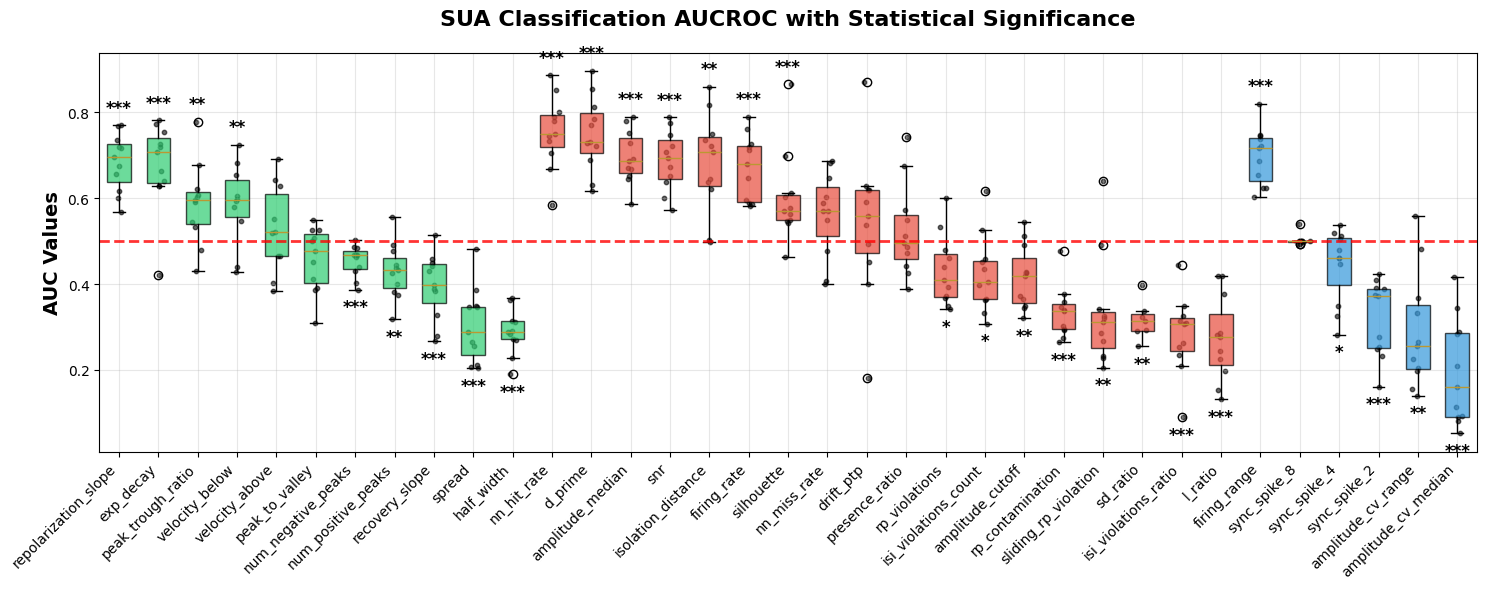

In [ ]:
# Significance plot for SUA data
if not sua_auc_df.empty:
    plot_aucroc_with_significance(
        sua_auc_df,
        title='SUA Classification AUCROC with Statistical Significance',
        figsize=(15, 6),
        save_path='sua_aucroc_significance.png'
    )
else:
    print("No SUA data available for significance testing")